# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Nabila Aufa Rafiqi Wardha Qoni'ah
- **Email:** nblafa27@gmail.com
- **ID Dicoding:** CDCC133D6X0156

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

- Kategori produk apa yang menghasilkan total revenue tertinggi pada transaksi e-commerce Olist selama periode September 2016 hingga Oktober 2018?
- Bagaimana tren revenue bulanan pada transaksi e-commerce Olist selama periode September 2016 hingga Oktober 2018?




Pertanyaan pertama berfokus pada kategori produk dengan total revenue tertinggi, sehingga hasilnya dapat diukur menggunakan total revenue dari setiap kategori produk. Pertanyaan ini relevan karena kategori dengan revenue tertinggi dapat membantu bisnis menentukan produk yang paling berkontribusi terhadap pendapatan. Pertanyaan juga dibatasi pada periode September 2016 hingga Oktober 2018 sesuai cakupan data yang tersedia.

Pertanyaan kedua berfokus pada perubahan revenue bulanan, sehingga hasilnya dapat diukur menggunakan total revenue per bulan. Pertanyaan ini relevan untuk memahami pola pendapatan dari waktu ke waktu dan membantu bisnis menentukan periode dengan performa penjualan tinggi atau rendah. Pertanyaan ini juga memiliki batas waktu yang jelas, yaitu selama periode September 2016 hingga Oktober 2018.

## Import Semua Packages/Library yang Digunakan

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

## Data Wrangling

In [ ]:
customers_df = pd.read_csv('olist_customers_dataset.csv')
orders_df = pd.read_csv('olist_orders_dataset.csv')
order_items_df = pd.read_csv('olist_order_items_dataset.csv')
payments_df = pd.read_csv('olist_order_payments_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')
category_df = pd.read_csv('product_category_name_translation.csv')

### Gathering Data

#### Load df ...

In [ ]:
customers_df = pd.read_csv('olist_customers_dataset.csv')
orders_df = pd.read_csv('olist_orders_dataset.csv')
order_items_df = pd.read_csv('olist_order_items_dataset.csv')
payments_df = pd.read_csv('olist_order_payments_dataset.csv')
products_df = pd.read_csv('olist_products_dataset.csv')
category_df = pd.read_csv('product_category_name_translation.csv')

customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
Data yang digunakan berasal dari Brazilian E-Commerce Public Dataset by Olist. Dataset ini terdiri dari beberapa tabel yang saling berkaitan, seperti data pelanggan, pesanan, item pesanan, pembayaran, produk, dan kategori produk. Data tersebut dapat digunakan untuk menganalisis revenue, tren penjualan bulanan, serta perilaku pelanggan melalui segmentasi RFM.

### Assessing Data

#### Identifying ... problem

In [ ]:
customers_df.info()
orders_df.info()
order_items_df.info()
payments_df.info()
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [ ]:
missing_values = {
    "customers_df": customers_df.isna().sum().sum(),
    "orders_df": orders_df.isna().sum().sum(),
    "order_items_df": order_items_df.isna().sum().sum(),
    "payments_df": payments_df.isna().sum().sum(),
    "products_df": products_df.isna().sum().sum()
}

missing_values

{'customers_df': np.int64(0),
 'orders_df': np.int64(4908),
 'order_items_df': np.int64(0),
 'payments_df': np.int64(0),
 'products_df': np.int64(2448)}

**Steps to Take:**
- Mengecek jumlah data dan kolom pada setiap dataset
- Mengidentifikasi missing values pada beberapa kolom
- Meninjau tipe data untuk memastikan kesesuaian analisis

**Insight:**
Dari hasil pengecekan, terlihat bahwa beberapa dataset memiliki missing values, terutama pada kolom terkait produk dan tanggal pengiriman. Selain itu, beberapa kolom tanggal masih bertipe object sehingga perlu dikonversi ke tipe datetime untuk analisis lebih lanjut.

### Cleaning Data

#### Fixing ... problem

In [ ]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'], errors='coerce')
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'], errors='coerce')
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'], errors='coerce')
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'], errors='coerce')
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'], errors='coerce')

# Menghapus data produk yang tidak memiliki kategori
products_df = products_df.dropna(subset=['product_category_name'])

# Mengecek ulang hasil cleaning
orders_df.info()
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 32341 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---

**Insight:**
Setelah proses cleaning, kolom tanggal pada orders_df sudah berubah menjadi tipe datetime sehingga dapat digunakan untuk analisis berbasis waktu. Data produk yang tidak memiliki kategori juga sudah dihapus, sehingga kolom product_category_name tidak lagi memiliki missing value. Namun, masih terdapat sedikit missing value pada beberapa kolom dimensi produk seperti berat, panjang, tinggi, dan lebar. Karena kolom tersebut tidak digunakan dalam analisis revenue kategori produk maupun tren revenue bulanan, missing value tersebut tidak memengaruhi hasil analisis utama.

## Exploratory Data Analysis (EDA)

### Explore ...

In [8]:
# =========================
# Persiapan Data untuk EDA
# =========================

# Mengubah kolom tanggal menjadi datetime
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

# Menghapus produk yang tidak memiliki kategori
products_clean_df = products_df.dropna(subset=["product_category_name"]).copy()

# Menggabungkan payment per order agar payment_value tidak terduplikasi saat digabung dengan item
payments_order_df = (
    payments_df
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    )
)

# Menggabungkan informasi item per order
items_order_df = (
    order_items_df
    .groupby("order_id", as_index=False)
    .agg(
        item_price=("price", "sum"),
        freight_value=("freight_value", "sum"),
        total_items=("order_item_id", "count")
    )
)

# Dataset level order untuk analisis revenue bulanan dan numerik
order_level_df = (
    orders_df
    .merge(customers_df, on="customer_id", how="left")
    .merge(payments_order_df, on="order_id", how="left")
    .merge(items_order_df, on="order_id", how="left")
)

order_level_df["month_year"] = order_level_df["order_purchase_timestamp"].dt.to_period("M").astype(str)
order_level_df["delivery_days"] = (
    order_level_df["order_delivered_customer_date"] - order_level_df["order_purchase_timestamp"]
).dt.days

# Dataset level item untuk analisis kategori produk
items_analysis_df = (
    order_items_df
    .merge(products_clean_df[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_df, on="product_category_name", how="left")
    .merge(orders_df[["order_id", "customer_id", "order_status", "order_purchase_timestamp"]], on="order_id", how="left")
    .merge(customers_df[["customer_id", "customer_state"]], on="customer_id", how="left")
)

items_analysis_df["month_year"] = items_analysis_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Revenue kategori produk menggunakan harga produk, bukan payment_value,
# karena payment_value bersifat order-level dan bisa terduplikasi saat digabung ke item.
items_analysis_df["revenue"] = items_analysis_df["price"]

# Filter periode sesuai pertanyaan bisnis: September 2016 - Oktober 2018
start_date = pd.Timestamp("2016-09-01")
end_date = pd.Timestamp("2018-11-01")

order_level_df = order_level_df[
    (order_level_df["order_purchase_timestamp"] >= start_date) &
    (order_level_df["order_purchase_timestamp"] < end_date)
].copy()

items_analysis_df = items_analysis_df[
    (items_analysis_df["order_purchase_timestamp"] >= start_date) &
    (items_analysis_df["order_purchase_timestamp"] < end_date)
].copy()

print("Jumlah order:", order_level_df["order_id"].nunique())
print("Periode data:", order_level_df["order_purchase_timestamp"].min(), "sampai", order_level_df["order_purchase_timestamp"].max())
print("Total payment/revenue order-level:", round(order_level_df["payment_value"].sum(), 2))
print("Total revenue produk/item:", round(items_analysis_df["revenue"].sum(), 2))
print("Total kategori produk:", items_analysis_df["product_category_name_english"].nunique())

Jumlah order: 99441
Periode data: 2016-09-04 21:15:19 sampai 2018-10-17 17:30:18
Total payment/revenue order-level: 16008872.12
Total revenue produk/item: 13591643.7
Total kategori produk: 71


**Insight:** **Insight:**

Dataset berisi 99.441 order dengan periode transaksi dari September 2016 hingga Oktober 2018. Total revenue berdasarkan `payment_value` adalah 16.008.872,12, sedangkan total revenue produk berdasarkan `price` adalah 13.591.643,70. Perbedaan ini terjadi karena `payment_value` berada pada level order, sementara `price` berada pada level item. Oleh karena itu, analisis revenue bulanan menggunakan `payment_value`, sedangkan analisis kategori produk menggunakan `price`.

EDA Univariate dan Numerik

In [9]:
# =========================
# EDA Univariate & Numerik
# =========================

numeric_cols = [
    "payment_value",
    "item_price",
    "freight_value",
    "total_items",
    "payment_installments",
    "delivery_days"
]

numeric_eda_df = order_level_df[numeric_cols].dropna()

summary_stat_df = numeric_eda_df.describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).T

summary_stat_df["variance"] = numeric_eda_df.var(numeric_only=True)
summary_stat_df["skewness"] = numeric_eda_df.skew(numeric_only=True)
summary_stat_df["kurtosis"] = numeric_eda_df.kurtosis(numeric_only=True)

summary_stat_df.round(2)

,count,mean,std,min,5%,25%,50%,75%,95%,max,variance,skewness,kurtosis
payment_value,96475.0,159.85,218.82,9.59,32.38,61.88,105.28,176.33,446.32,13664.08,47880.06,9.37,249.20
item_price,96475.0,137.04,209.05,0.85,19.00,45.90,86.50,149.90,399.00,13440.00,43701.14,9.89,277.01
freight_value,96475.0,22.79,21.56,0.00,7.88,13.85,17.17,24.02,54.78,1794.96,464.81,12.28,586.00
total_items,96475.0,1.14,0.54,1.00,1.00,1.00,1.00,1.00,2.00,21.00,0.29,7.56,116.31
payment_installments,96475.0,2.93,2.71,0.00,1.00,1.00,2.00,4.00,10.00,24.00,7.36,1.60,2.38
delivery_days,96475.0,12.09,9.55,0.00,3.00,6.00,10.00,15.00,29.00,209.00,91.22,3.83,39.28


**Insight:**

Sebagian besar variabel numerik memiliki distribusi yang miring ke kanan, terlihat dari nilai skewness yang positif. Variabel `payment_value`, `item_price`, dan `freight_value` memiliki nilai maksimum yang jauh lebih besar dibanding median, sehingga terdapat indikasi outlier pada transaksi bernilai tinggi. Selain itu, nilai kurtosis yang tinggi menunjukkan bahwa distribusi data tidak normal dan memiliki ekor yang panjang. Oleh karena itu, analisis selanjutnya perlu memperhatikan median, percentile, dan visualisasi boxplot agar tidak hanya bergantung pada rata-rata.

Visualisasi histogram, KDE, dan boxplot

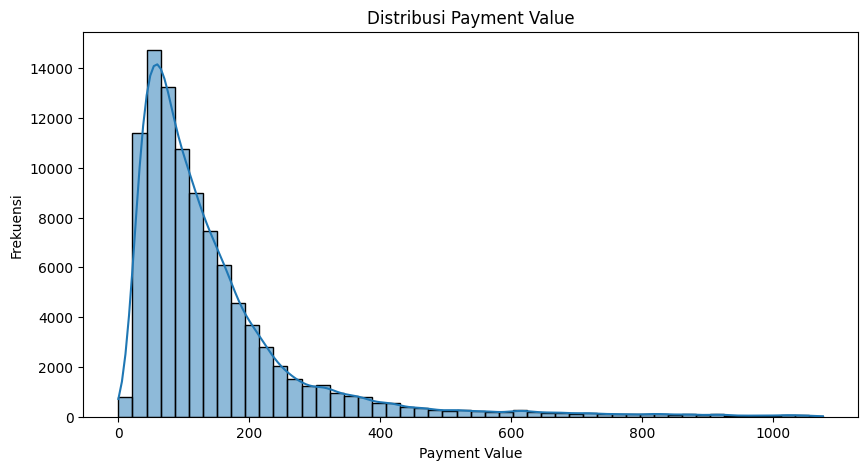

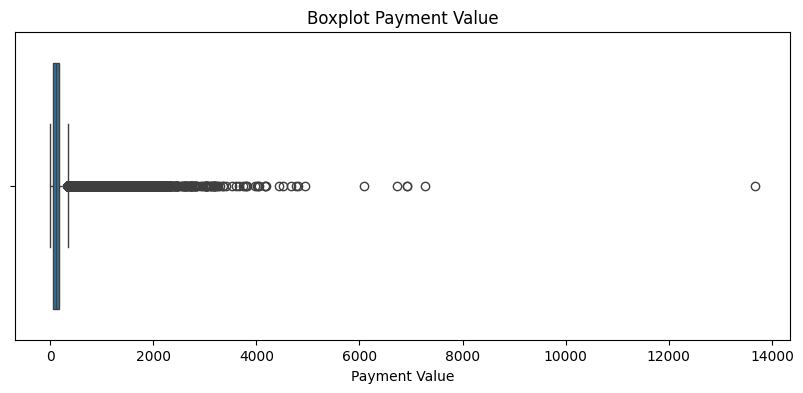

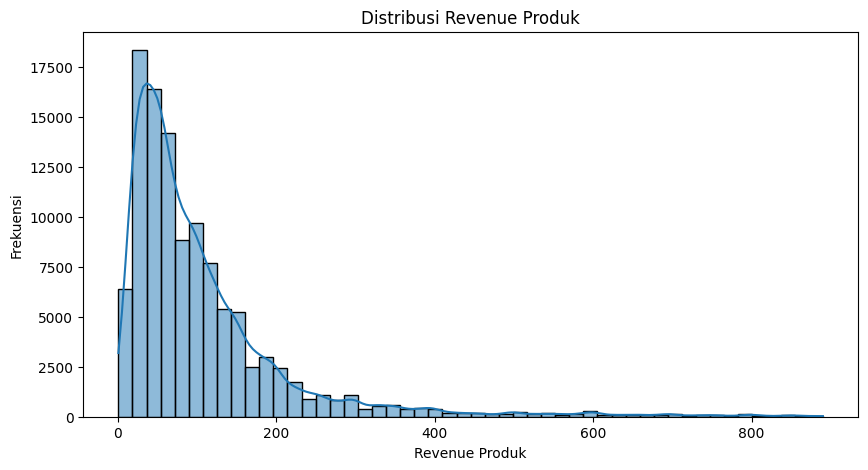

In [10]:
# Histogram dan KDE payment_value
payment_99 = order_level_df["payment_value"].quantile(0.99)

plt.figure(figsize=(10, 5))
sns.histplot(
    order_level_df[order_level_df["payment_value"] <= payment_99]["payment_value"],
    bins=50,
    kde=True
)
plt.title("Distribusi Payment Value")
plt.xlabel("Payment Value")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot payment_value
plt.figure(figsize=(10, 4))
sns.boxplot(x=order_level_df["payment_value"])
plt.title("Boxplot Payment Value")
plt.xlabel("Payment Value")
plt.show()

# Histogram revenue produk/item
revenue_99 = items_analysis_df["revenue"].quantile(0.99)

plt.figure(figsize=(10, 5))
sns.histplot(
    items_analysis_df[items_analysis_df["revenue"] <= revenue_99]["revenue"],
    bins=50,
    kde=True
)
plt.title("Distribusi Revenue Produk")
plt.xlabel("Revenue Produk")
plt.ylabel("Frekuensi")
plt.show()

**Insight:**

Distribusi `payment_value` dan `revenue produk` cenderung miring ke kanan. Sebagian besar transaksi memiliki nilai pembayaran dan revenue produk yang relatif kecil, tetapi terdapat beberapa transaksi dengan nilai sangat tinggi yang terlihat sebagai outlier pada boxplot. Hal ini menunjukkan bahwa data revenue tidak berdistribusi normal dan perlu dianalisis menggunakan median, percentile, serta visualisasi boxplot agar interpretasinya tidak terlalu dipengaruhi oleh outlier.

Uji normalitas

In [11]:
# =========================
# Uji Normalitas
# =========================

normality_result = []

for col in numeric_cols:
    sample = numeric_eda_df[col].dropna()
    sample = sample.sample(min(5000, len(sample)), random_state=42)

    stat, pvalue = stats.normaltest(sample)

    normality_result.append({
        "variable": col,
        "normaltest_statistic": stat,
        "p_value": pvalue,
        "interpretation": "Tidak normal" if pvalue < 0.05 else "Mendekati normal"
    })

normality_result_df = pd.DataFrame(normality_result)
normality_result_df

,variable,normaltest_statistic,p_value,interpretation
0,payment_value,5525.087136,0.000000e+00,Tidak normal
1,item_price,5640.241017,0.000000e+00,Tidak normal
2,freight_value,5247.744507,0.000000e+00,Tidak normal
3,total_items,8454.429579,0.000000e+00,Tidak normal
4,payment_installments,1341.166052,5.881555e-292,Tidak normal
5,delivery_days,4302.558374,0.000000e+00,Tidak normal


**Insight:**

Hasil uji normalitas menunjukkan bahwa seluruh variabel numerik memiliki p-value kurang dari 0,05, sehingga dapat disimpulkan bahwa data tidak berdistribusi normal. Hal ini sejalan dengan hasil histogram dan boxplot sebelumnya yang menunjukkan distribusi miring ke kanan serta adanya outlier. Oleh karena itu, analisis revenue lebih tepat dibantu dengan median, percentile, dan visualisasi distribusi, bukan hanya berdasarkan rata-rata.

Q-Q plot

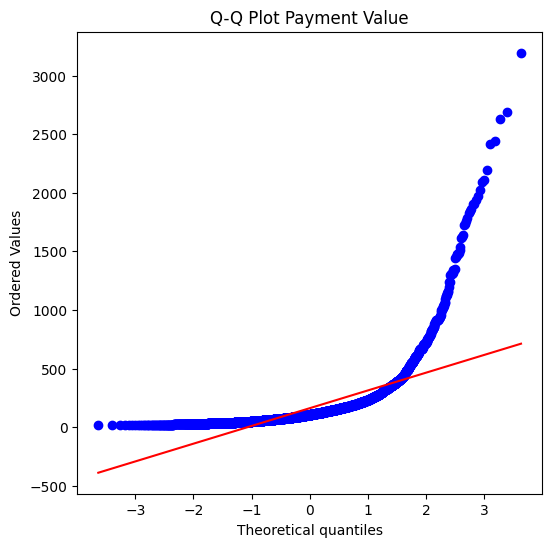

In [12]:
# Q-Q plot payment_value
sample_payment = order_level_df["payment_value"].dropna()
sample_payment = sample_payment.sample(min(5000, len(sample_payment)), random_state=42)

plt.figure(figsize=(6, 6))
stats.probplot(sample_payment, dist="norm", plot=plt)
plt.title("Q-Q Plot Payment Value")
plt.show()

**Insight:**

Q-Q plot menunjukkan bahwa titik data `payment_value` tidak mengikuti garis diagonal normal, terutama pada bagian kanan atas. Hal ini mengindikasikan bahwa distribusi `payment_value` tidak normal dan memiliki outlier pada transaksi bernilai tinggi. Hasil ini konsisten dengan uji normalitas, histogram, dan boxplot sebelumnya.

EDA Kategorikal

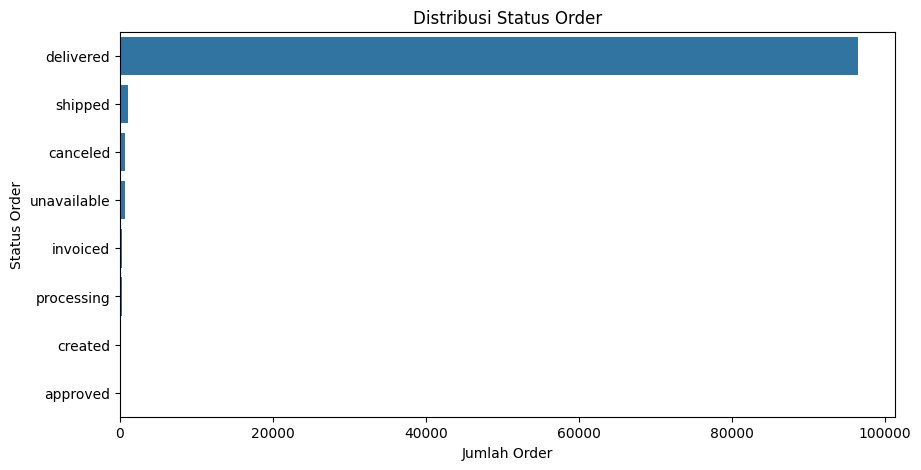

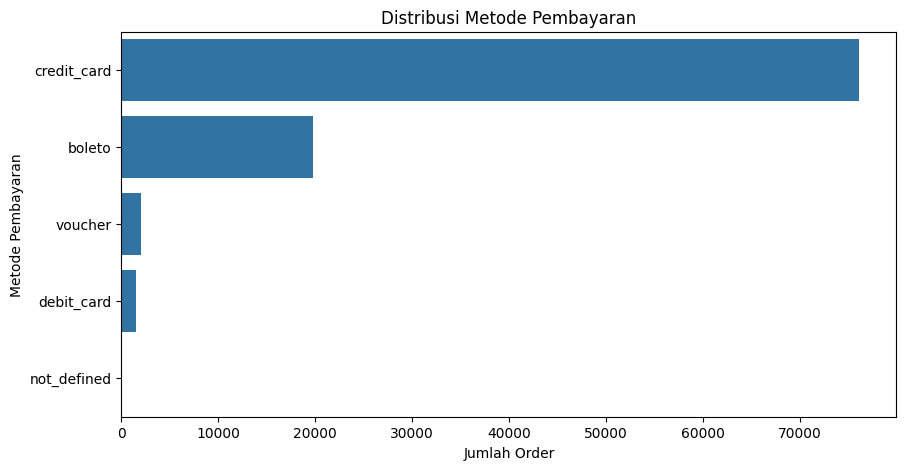

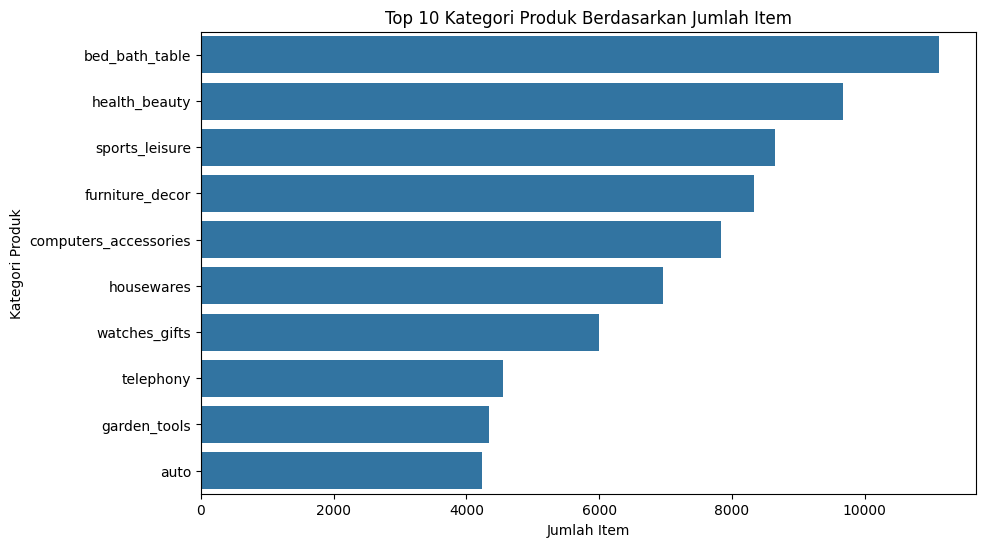

In [13]:
# =========================
# EDA Kategorikal
# =========================

# Distribusi status order
plt.figure(figsize=(10, 5))
sns.countplot(
    data=order_level_df,
    y="order_status",
    order=order_level_df["order_status"].value_counts().index
)
plt.title("Distribusi Status Order")
plt.xlabel("Jumlah Order")
plt.ylabel("Status Order")
plt.show()

# Distribusi metode pembayaran
plt.figure(figsize=(10, 5))
sns.countplot(
    data=order_level_df,
    y="payment_type",
    order=order_level_df["payment_type"].value_counts().index
)
plt.title("Distribusi Metode Pembayaran")
plt.xlabel("Jumlah Order")
plt.ylabel("Metode Pembayaran")
plt.show()

# Top 10 kategori produk berdasarkan jumlah item
top_category_count = items_analysis_df["product_category_name_english"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_category_count.values,
    y=top_category_count.index
)
plt.title("Top 10 Kategori Produk Berdasarkan Jumlah Item")
plt.xlabel("Jumlah Item")
plt.ylabel("Kategori Produk")
plt.show()

**Insight:**

Mayoritas order memiliki status `delivered`, sehingga sebagian besar transaksi dalam dataset berhasil diselesaikan. Dari sisi metode pembayaran, `credit_card` menjadi metode yang paling sering digunakan, disusul oleh `boleto`. Pada kategori produk, `bed_bath_table`, `health_beauty`, dan `sports_leisure` menjadi kategori dengan jumlah item terbanyak. Hal ini menunjukkan bahwa beberapa kategori produk memiliki volume transaksi yang lebih dominan dibanding kategori lainnya.

Boxplot per kategori

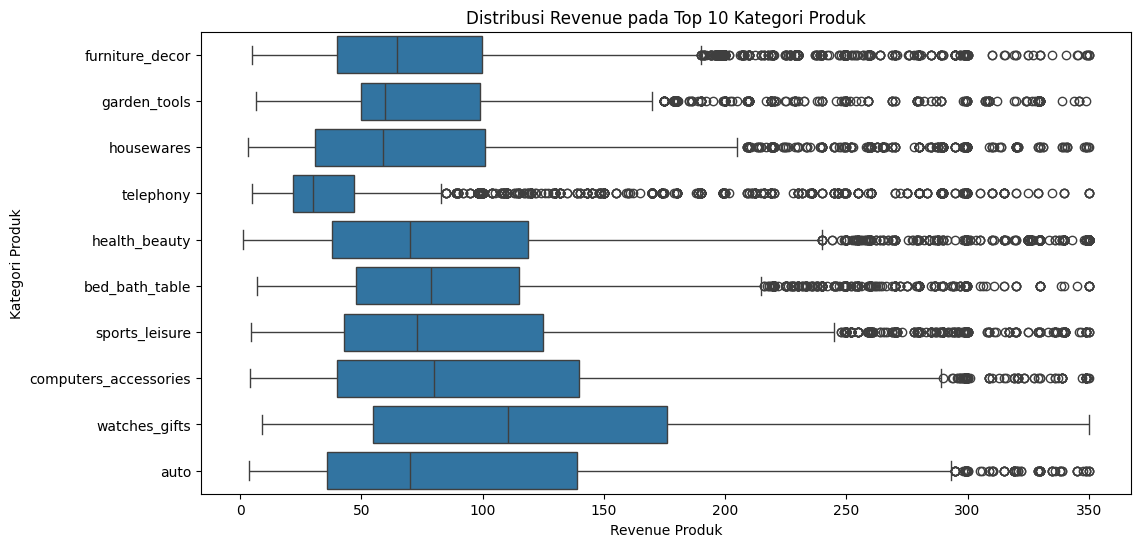

In [14]:
# Boxplot revenue per kategori produk
top_categories = items_analysis_df["product_category_name_english"].value_counts().head(10).index

category_revenue_sample = items_analysis_df[
    (items_analysis_df["product_category_name_english"].isin(top_categories)) &
    (items_analysis_df["revenue"] <= items_analysis_df["revenue"].quantile(0.95))
]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=category_revenue_sample,
    x="revenue",
    y="product_category_name_english"
)
plt.title("Distribusi Revenue pada Top 10 Kategori Produk")
plt.xlabel("Revenue Produk")
plt.ylabel("Kategori Produk")
plt.show()

**Insight:**

Boxplot menunjukkan bahwa setiap kategori produk memiliki sebaran revenue yang berbeda. Beberapa kategori seperti `watches_gifts`, `computers_accessories`, dan `auto` memiliki variasi revenue yang lebih besar dibanding kategori lain. Selain itu, terdapat banyak outlier pada beberapa kategori, yang menunjukkan adanya produk dengan nilai revenue jauh lebih tinggi dibanding mayoritas transaksi pada kategori tersebut.

EDA Multivariate

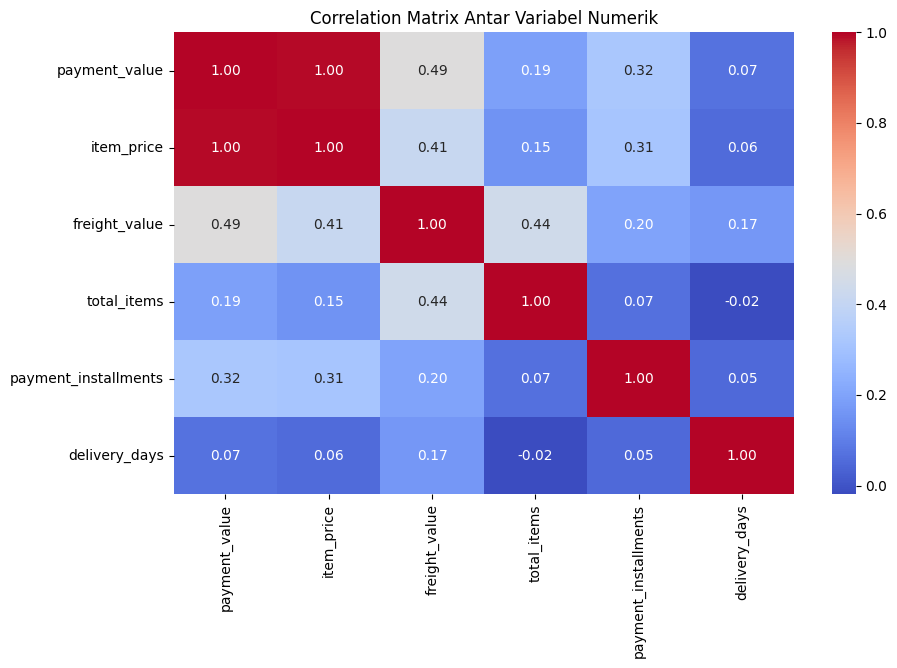

In [15]:
# =========================
# EDA Multivariate
# =========================

corr_cols = [
    "payment_value",
    "item_price",
    "freight_value",
    "total_items",
    "payment_installments",
    "delivery_days"
]

corr_df = order_level_df[corr_cols].dropna().corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix Antar Variabel Numerik")
plt.show()

**Insight:**

Correlation matrix menunjukkan bahwa `payment_value` memiliki korelasi sangat kuat dengan `item_price`. Hal ini wajar karena total pembayaran order sangat dipengaruhi oleh harga item yang dibeli. Sementara itu, `freight_value` memiliki korelasi sedang dengan `payment_value`, sedangkan `delivery_days` memiliki korelasi rendah terhadap variabel pembayaran. Artinya, lama pengiriman tidak memiliki hubungan linear yang kuat dengan nilai transaksi.

Scatter plot dan regression line

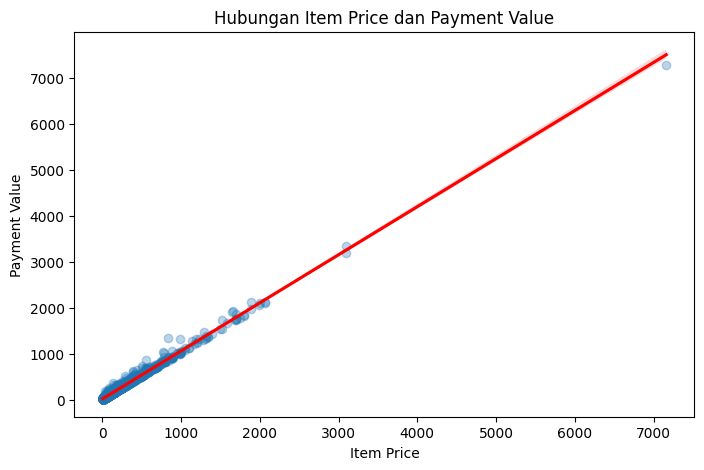

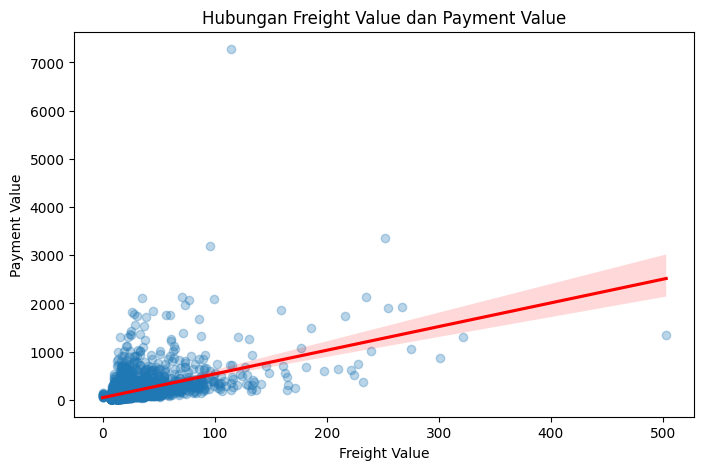

In [16]:
# Hubungan item_price dan payment_value
plt.figure(figsize=(8, 5))
sns.regplot(
    data=order_level_df.sample(min(5000, len(order_level_df)), random_state=42),
    x="item_price",
    y="payment_value",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Hubungan Item Price dan Payment Value")
plt.xlabel("Item Price")
plt.ylabel("Payment Value")
plt.show()

# Hubungan freight_value dan payment_value
plt.figure(figsize=(8, 5))
sns.regplot(
    data=order_level_df.sample(min(5000, len(order_level_df)), random_state=42),
    x="freight_value",
    y="payment_value",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Hubungan Freight Value dan Payment Value")
plt.xlabel("Freight Value")
plt.ylabel("Payment Value")
plt.show()

**Insight:**

Scatter plot menunjukkan bahwa `item_price` memiliki hubungan positif yang sangat kuat dengan `payment_value`. Semakin tinggi harga item dalam order, semakin tinggi pula nilai pembayaran order. Sementara itu, `freight_value` juga memiliki hubungan positif dengan `payment_value`, tetapi hubungannya tidak sekuat `item_price`. Hal ini menunjukkan bahwa nilai pembayaran order lebih banyak dipengaruhi oleh harga produk dibandingkan biaya pengiriman.

Pairplot

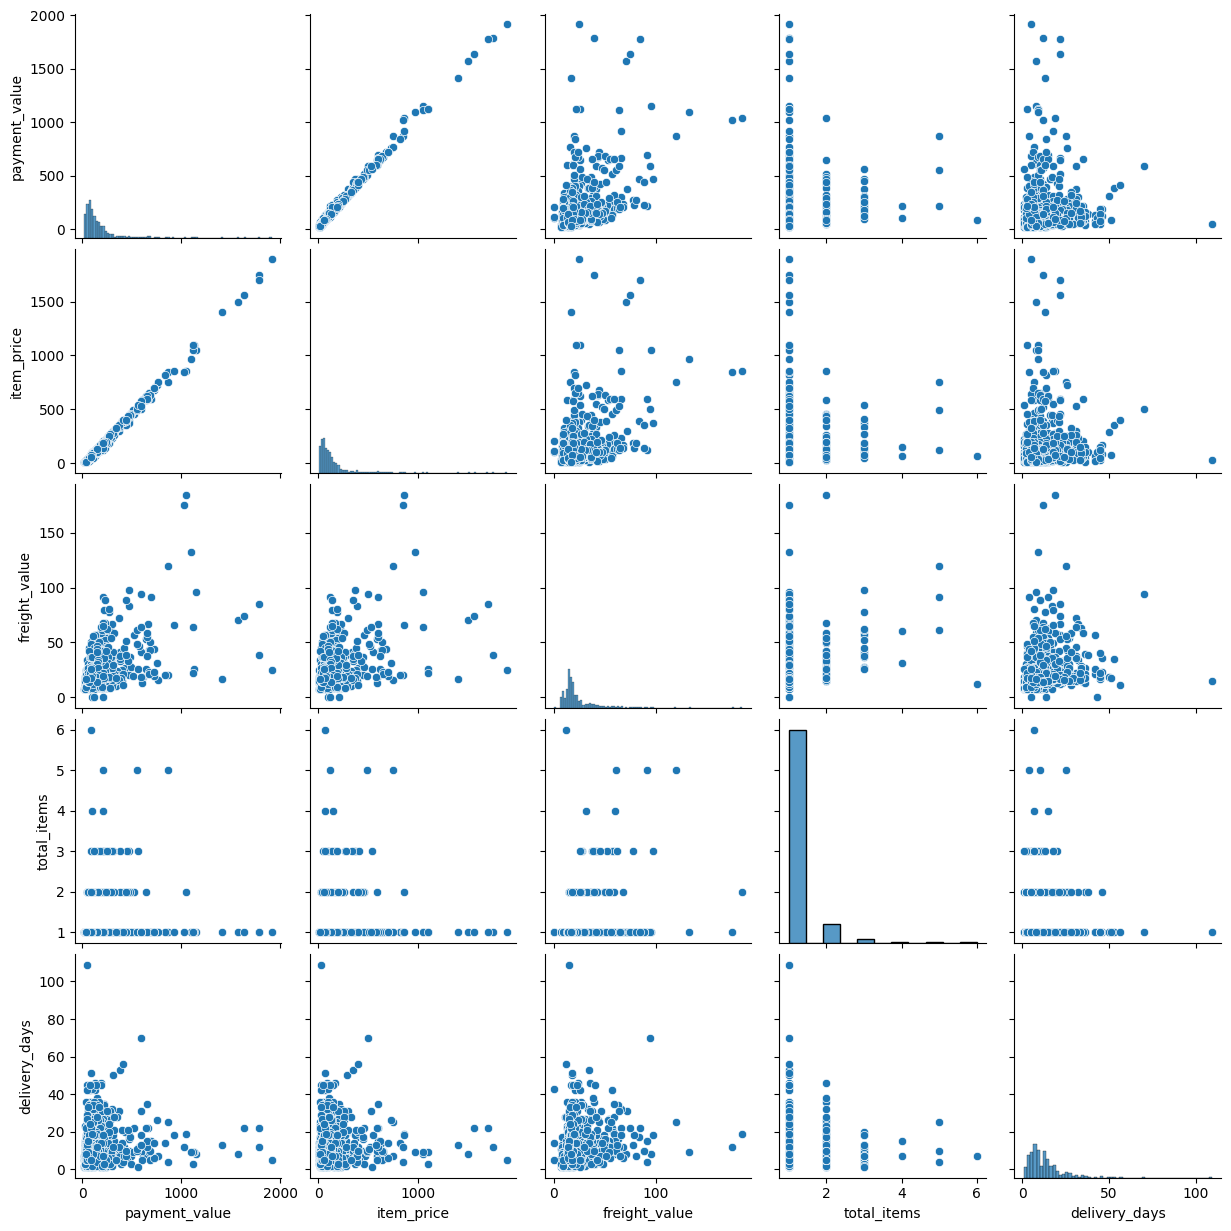

In [17]:
pairplot_cols = [
    "payment_value",
    "item_price",
    "freight_value",
    "total_items",
    "delivery_days"
]

pairplot_sample = order_level_df[pairplot_cols].dropna().sample(
    min(1000, len(order_level_df[pairplot_cols].dropna())),
    random_state=42
)

sns.pairplot(pairplot_sample)
plt.show()

**Insight:**

Pairplot menunjukkan hubungan antar variabel numerik dalam dataset. Pola paling kuat terlihat antara `item_price` dan `payment_value`, di mana semakin tinggi harga item, semakin tinggi pula nilai pembayaran. Variabel `freight_value` juga memiliki hubungan positif dengan `payment_value`, tetapi sebarannya lebih menyebar. Sementara itu, `delivery_days` dan `total_items` tidak menunjukkan hubungan linear yang kuat terhadap nilai pembayaran.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

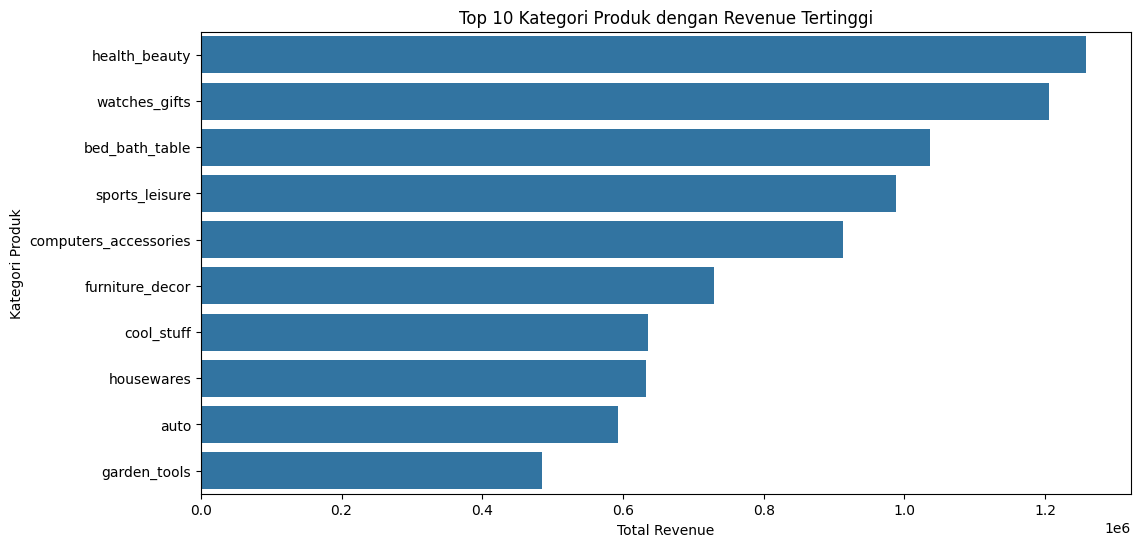

,product_category_name_english,total_revenue
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


In [18]:
# =========================
# Pertanyaan 1:
# Kategori produk apa yang menghasilkan total revenue tertinggi?
# =========================

top_category_revenue = (
    items_analysis_df
    .groupby("product_category_name_english", as_index=False)
    .agg(total_revenue=("revenue", "sum"))
    .sort_values(by="total_revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_category_revenue,
    x="total_revenue",
    y="product_category_name_english"
)
plt.title("Top 10 Kategori Produk dengan Revenue Tertinggi")
plt.xlabel("Total Revenue")
plt.ylabel("Kategori Produk")
plt.show()

top_category_revenue

**Insight:**

Kategori `health_beauty` menghasilkan total revenue tertinggi, diikuti oleh `watches_gifts` dan `bed_bath_table`. Hal ini menunjukkan bahwa kategori tersebut memiliki kontribusi pendapatan produk yang paling besar selama periode analisis. Revenue kategori dihitung menggunakan kolom `price` karena analisis dilakukan pada level item produk, sehingga hasilnya tidak terduplikasi oleh nilai pembayaran order.

### Pertanyaan 2:

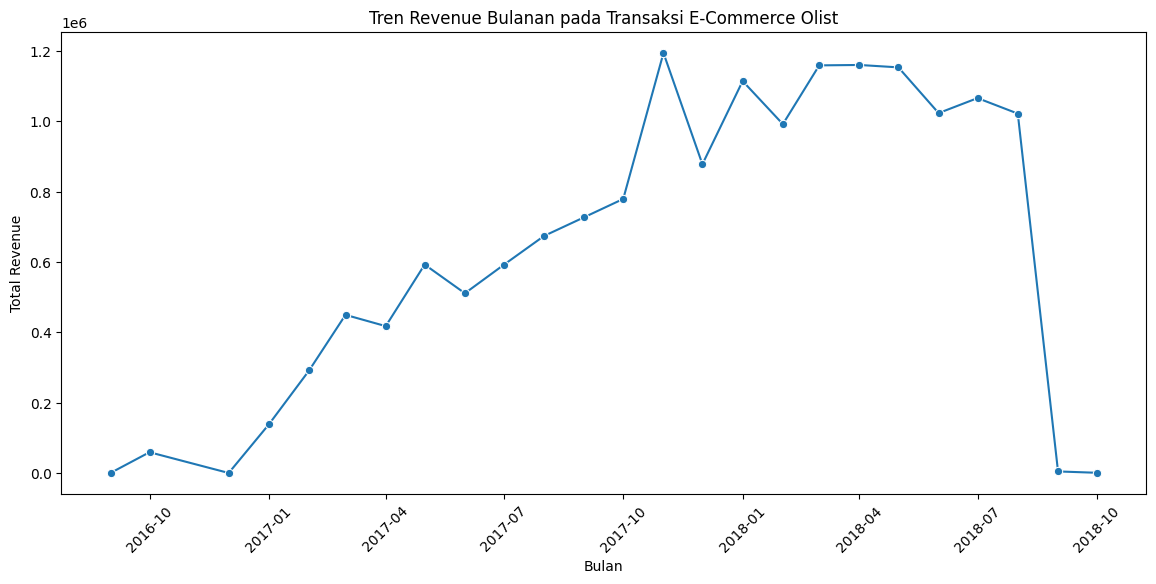

,month_year,total_revenue,total_order
0,2016-09-01,252.24,4
1,2016-10-01,59090.48,324
2,2016-12-01,19.62,1
3,2017-01-01,138488.04,800
4,2017-02-01,291908.01,1780
5,2017-03-01,449863.60,2682
6,2017-04-01,417788.03,2404
7,2017-05-01,592918.82,3700
8,2017-06-01,511276.38,3245
9,2017-07-01,592382.92,4026


In [19]:
# =========================
# Pertanyaan 2:
# Bagaimana tren revenue bulanan?
# =========================

monthly_revenue_df = (
    order_level_df
    .groupby("month_year", as_index=False)
    .agg(
        total_revenue=("payment_value", "sum"),
        total_order=("order_id", "nunique")
    )
)

monthly_revenue_df["month_year"] = pd.to_datetime(monthly_revenue_df["month_year"])
monthly_revenue_df = monthly_revenue_df.sort_values("month_year")

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_revenue_df,
    x="month_year",
    y="total_revenue",
    marker="o"
)
plt.title("Tren Revenue Bulanan pada Transaksi E-Commerce Olist")
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

monthly_revenue_df

**Insight:**

Tren revenue bulanan menunjukkan bahwa revenue mulai meningkat sejak awal tahun 2017 dan mencapai nilai tertinggi pada November 2017. Sepanjang awal hingga pertengahan 2018, revenue cenderung stabil pada kisaran yang cukup tinggi meskipun mengalami beberapa fluktuasi. Revenue pada September dan Oktober 2018 terlihat sangat rendah karena jumlah order pada periode tersebut sangat sedikit, sehingga tidak dapat langsung disimpulkan sebagai penurunan performa bisnis.

## Analisis Lanjutan (Opsional)

In [20]:
# Analisis tambahan: kontribusi revenue 5 kategori teratas
top5_category_revenue = (
    items_analysis_df
    .groupby("product_category_name_english", as_index=False)
    .agg(total_revenue=("revenue", "sum"))
    .sort_values(by="total_revenue", ascending=False)
    .head(5)
)

top5_category_revenue

,product_category_name_english,total_revenue
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32


**Insight:**

Lima kategori dengan kontribusi revenue produk terbesar adalah `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, dan `computers_accessories`. Analisis ini menggunakan kolom `revenue` yang berasal dari `price`, sehingga lebih sesuai untuk melihat kontribusi kategori produk pada level item.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**  
  Kategori produk dengan total revenue tertinggi selama periode September 2016 hingga Oktober 2018 adalah `health_beauty` dengan total revenue sekitar 1.258.681,34. Kategori berikutnya yang juga memberikan kontribusi besar adalah `watches_gifts`, `bed_bath_table`, `sports_leisure`, dan `computers_accessories`. Hal ini menunjukkan bahwa kategori kecantikan/kesehatan, hadiah, kebutuhan rumah tangga, olahraga, dan aksesoris komputer merupakan kategori penting dalam kontribusi pendapatan produk.

- **Conclusion pertanyaan 2:**  
  Revenue bulanan menunjukkan tren peningkatan sejak awal tahun 2017 dan mencapai nilai tertinggi pada November 2017 dengan total revenue sekitar 1.194.882,80. Sepanjang awal hingga pertengahan 2018, revenue berada pada level yang cukup tinggi meskipun mengalami fluktuasi. Penurunan tajam pada September dan Oktober 2018 tidak dapat langsung dianggap sebagai penurunan performa bisnis karena jumlah order pada periode tersebut sangat sedikit dan cakupan data kemungkinan tidak lengkap.

**Rekomendasi Action Item:**
- Bisnis dapat memprioritaskan kategori dengan revenue tertinggi seperti `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, dan `computers_accessories` dalam strategi promosi, pengelolaan stok, serta kampanye penjualan.
- Perusahaan dapat memanfaatkan periode dengan revenue tinggi, terutama sekitar akhir tahun seperti November, untuk menjalankan campaign, diskon, atau promosi musiman agar potensi pendapatan dapat dimaksimalkan.
- Analisis revenue bulanan sebaiknya tetap mempertimbangkan kelengkapan data, terutama untuk periode September dan Oktober 2018, agar keputusan bisnis tidak diambil berdasarkan data yang belum lengkap.